# 📊 Campus Placement Analytics

# 03 - Data Visualization

## Objective

This notebook presents visual insights from the engineering placement dataset using Python visualization libraries. The charts help understand placement trends, academic performance, recruiter preferences, and salary distribution.

### Tools Used

- Python
- Pandas
- Matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Asus/OneDrive/Desktop/Campus_Placement_Analytics/Python/Engineering_Placement_Final.csv")

placed = df[df["Placement_Status"]=="Placed"]

## 1. Placement Status Distribution

Visualize the number of placed and not placed students.

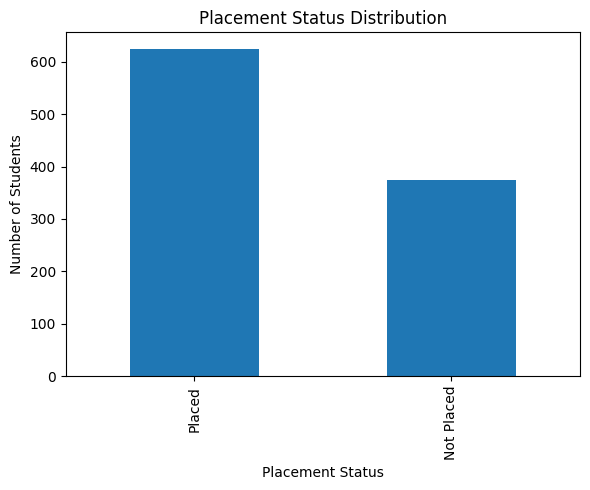

In [3]:
placement = df["Placement_Status"].value_counts()

plt.figure(figsize=(6,5))

placement.plot(kind="bar")

plt.title("Placement Status Distribution")

plt.xlabel("Placement Status")

plt.ylabel("Number of Students")

plt.tight_layout()

plt.show()

**Observation**

The chart compares the number of placed and not placed students, providing an overall view of placement success.

## 2. Branch-wise Student Distribution

### Objective

Visualize the number of students enrolled in each engineering branch.

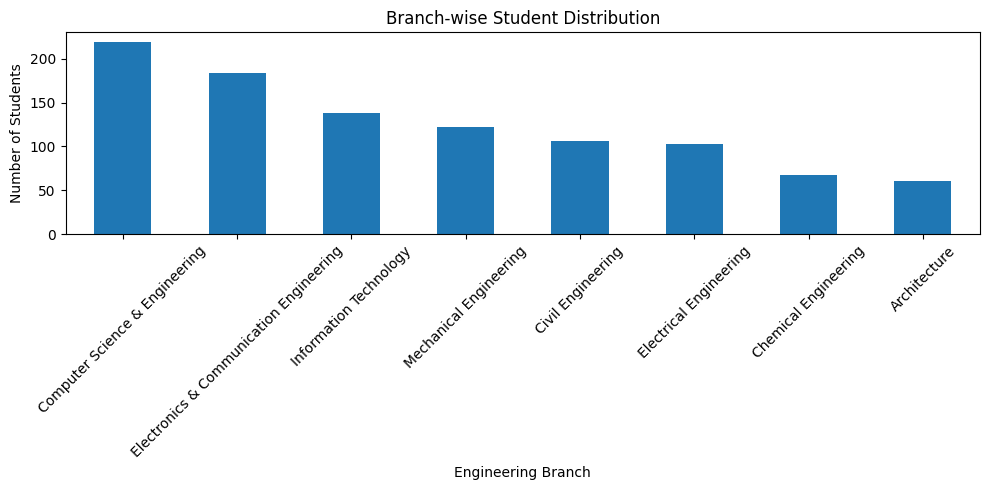

In [4]:
branch = df["Branch"].value_counts()

plt.figure(figsize=(10,5))

branch.plot(kind="bar")

plt.title("Branch-wise Student Distribution")

plt.xlabel("Engineering Branch")

plt.ylabel("Number of Students")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation

- The chart shows the distribution of students across different engineering branches.
- It helps identify branches with the highest and lowest student enrollment.
- This distribution provides context for branch-wise placement analysis.

## 3. Branch-wise Average Salary Package

### Objective

Compare the average salary package offered to placed students across engineering branches.

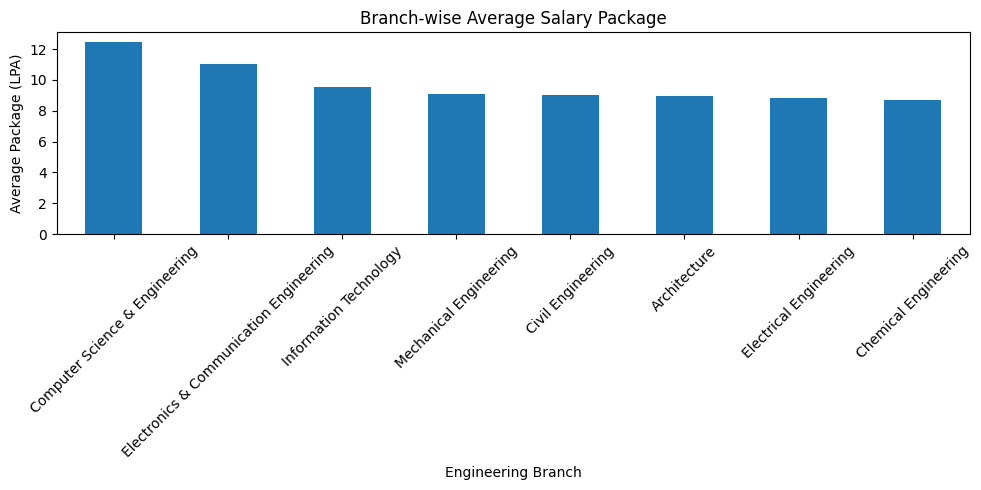

In [5]:
avg_package = (
    placed.groupby("Branch")["Package_LPA"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

avg_package.plot(kind="bar")

plt.title("Branch-wise Average Salary Package")

plt.xlabel("Engineering Branch")

plt.ylabel("Average Package (LPA)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation

- Average salary packages vary across engineering branches.
- Some branches consistently receive higher salary offers.
- This comparison highlights differences in placement opportunities among branches.

## 4. Top 10 Recruiting Companies

### Objective

Identify the companies that recruited the highest number of students.

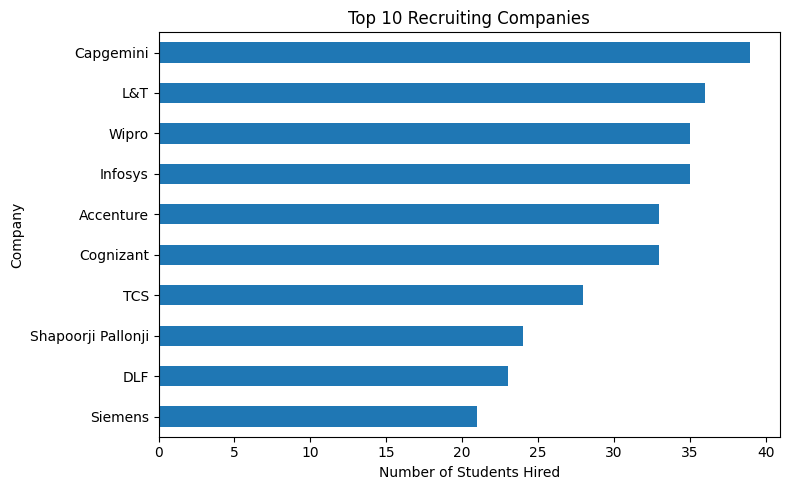

In [6]:
companies = placed["Company"].value_counts().head(10)

plt.figure(figsize=(8,5))

companies.sort_values().plot(kind="barh")

plt.title("Top 10 Recruiting Companies")

plt.xlabel("Number of Students Hired")

plt.ylabel("Company")

plt.tight_layout()

plt.show()

### Observation

- The chart highlights the most active recruiters.
- It shows which companies hired the largest number of students.
- This analysis helps identify major campus recruiters.

## 5. Job Role Distribution

### Objective

Analyze the distribution of job roles offered during campus placements.

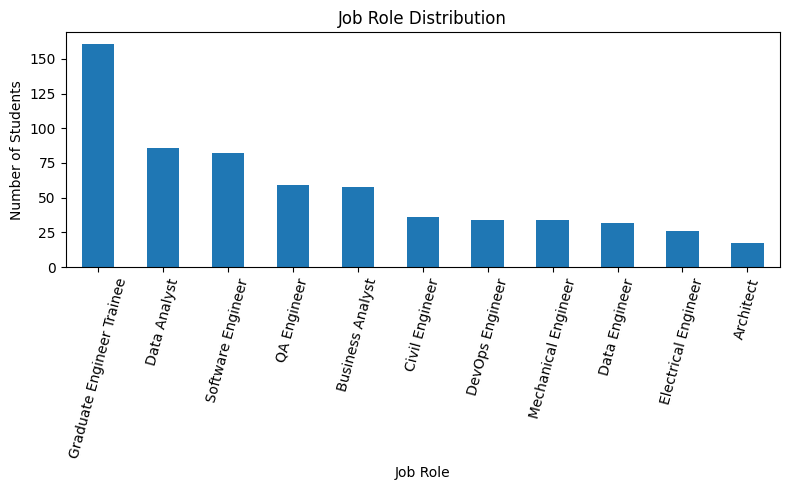

In [13]:
roles = placed["Job_Role"].value_counts()

plt.figure(figsize=(8,5))

roles.plot(kind="bar")

plt.title("Job Role Distribution")

plt.xlabel("Job Role")

plt.ylabel("Number of Students")

plt.xticks(rotation=75)

plt.tight_layout()

plt.show()

### Observation

- Multiple job roles were offered to students.
- Some roles were significantly more common than others.
- The distribution reflects the hiring demand across different job profiles.

## 6. Internship Experience vs Placement Status

### Objective

Analyze the relationship between internship experience and placement outcomes.

<Figure size 600x500 with 0 Axes>

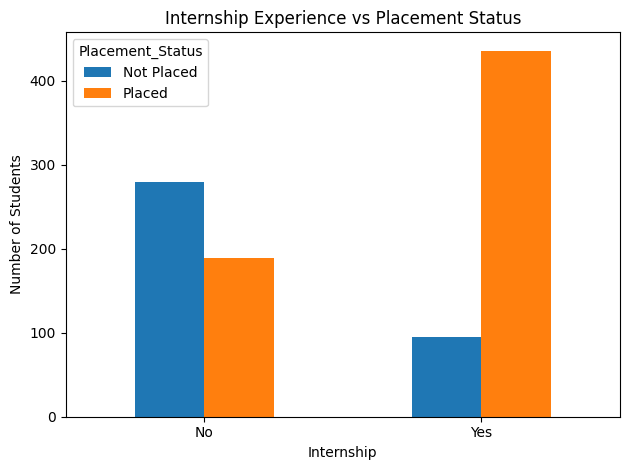

In [14]:
internship = pd.crosstab(
    df["Internship"],
    df["Placement_Status"]
)

plt.figure(figsize=(6,5))

internship.plot(kind="bar")

plt.title("Internship Experience vs Placement Status")

plt.xlabel("Internship")

plt.ylabel("Number of Students")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Observation

- Students with internship experience generally achieved better placement outcomes.
- Internship exposure appears to positively influence employability.
- Practical industry experience complements academic performance during placements.

## 7. Placement Type Distribution

### Objective

Visualize the proportion of placements through different recruitment channels.

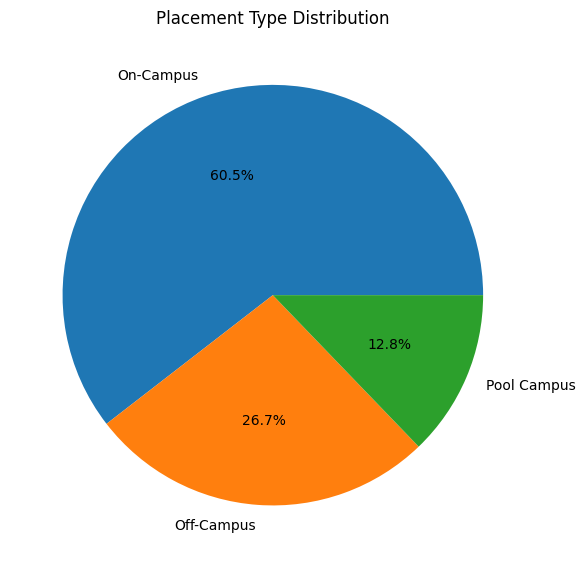

In [15]:
ptype = placed["Placement_Type"].value_counts()

plt.figure(figsize=(6,6))

ptype.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Placement Type Distribution")

plt.tight_layout()

plt.show()

### Observation

- Most students secured placements through on-campus recruitment.
- Off-campus and pool campus placements also contributed to the overall placement statistics.
- The chart illustrates the distribution of placement channels.

## 8. Placement Season Analysis

### Objective

Analyze the distribution of placements across different recruitment months.

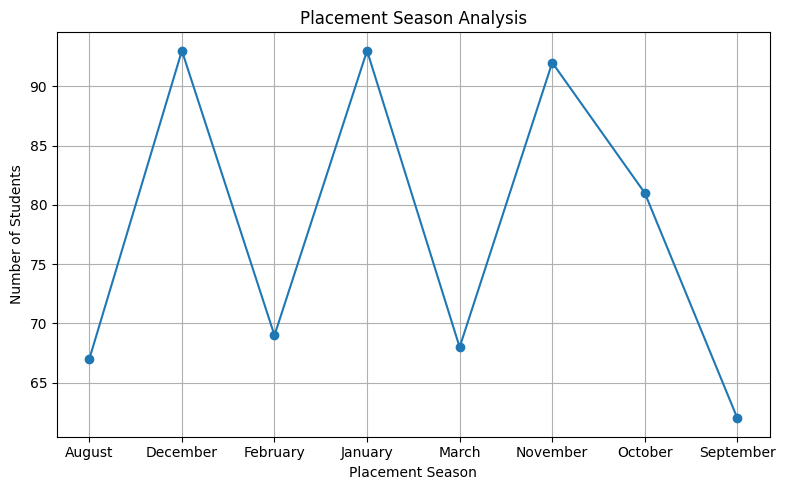

In [16]:
season = placed["Placement_Season"].value_counts().sort_index()

plt.figure(figsize=(8,5))

season.plot(
    kind="line",
    marker="o"
)

plt.title("Placement Season Analysis")

plt.xlabel("Placement Season")

plt.ylabel("Number of Students")

plt.grid(True)

plt.tight_layout()

plt.show()

### Observation

- Placement activities are spread across multiple recruitment months.
- Some months recorded higher recruitment activity than others.
- This helps identify peak campus placement periods.

## 9. Salary Package Distribution

### Objective

Analyze the distribution of salary packages offered to placed students.

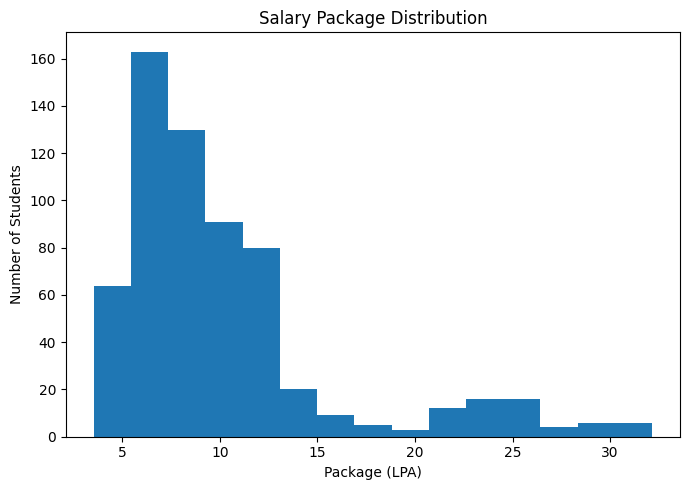

In [17]:
plt.figure(figsize=(7,5))

plt.hist(
    placed["Package_LPA"],
    bins=15
)

plt.title("Salary Package Distribution")

plt.xlabel("Package (LPA)")

plt.ylabel("Number of Students")

plt.tight_layout()

plt.show()

### Observation

- Most salary packages fall within a moderate range.
- A smaller number of students received significantly higher salary offers.
- The distribution highlights the spread of compensation among placed students.

## 10. CGPA vs Salary Package

### Objective

Examine the relationship between academic performance and salary package.

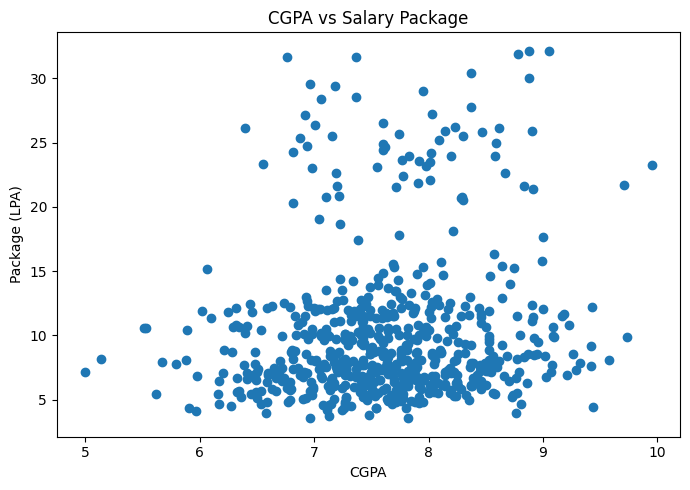

In [18]:
plt.figure(figsize=(7,5))

plt.scatter(
    placed["CGPA"],
    placed["Package_LPA"]
)

plt.title("CGPA vs Salary Package")

plt.xlabel("CGPA")

plt.ylabel("Package (LPA)")

plt.tight_layout()

plt.show()

### Observation

- Students with higher CGPA generally tend to receive higher salary packages.
- While academic performance influences salary, other factors also contribute to placement outcomes.
- The scatter plot helps visualize this relationship.

## 11. Correlation Analysis

### Objective

Visualize the relationships among numerical variables in the dataset.

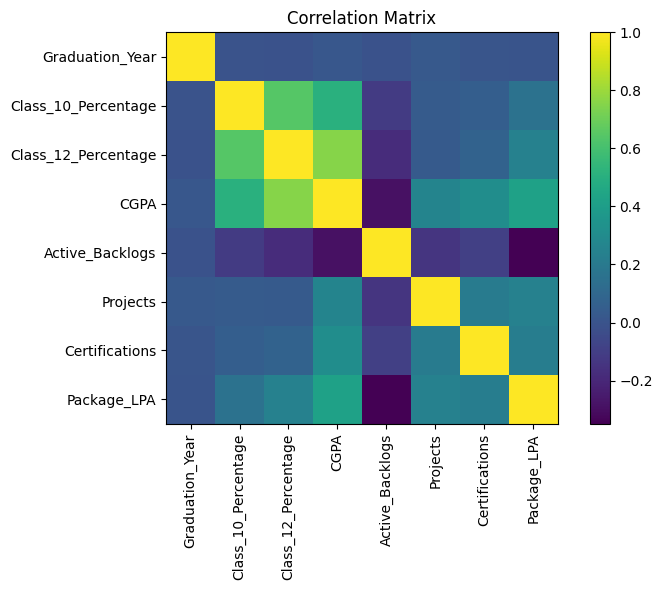

In [19]:
corr = df.select_dtypes(
    include=["int64","float64"]
).corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

### Observation

- The correlation matrix highlights relationships among numerical variables.
- Positive correlations indicate variables that tend to increase together, while negative correlations indicate inverse relationships.
- This analysis helps identify the factors most associated with academic and placement performance.

## 12. Projects and Certifications Analysis

### Objective

Compare the average number of projects and certifications between placed and not placed students.

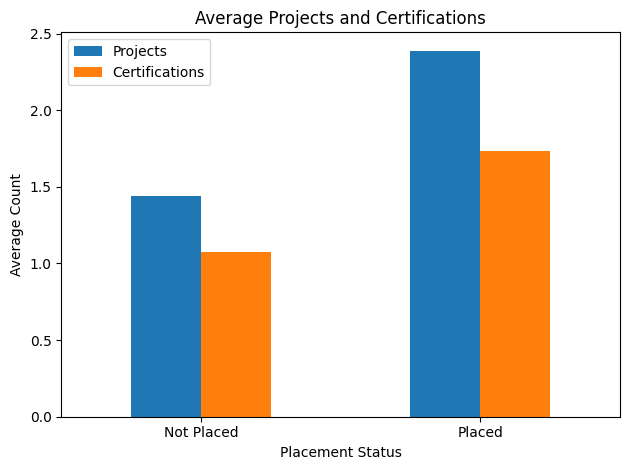

In [20]:
comparison = df.groupby(
    "Placement_Status"
)[
    ["Projects","Certifications"]
].mean()

comparison.plot(kind="bar")

plt.title("Average Projects and Certifications")

plt.xlabel("Placement Status")

plt.ylabel("Average Count")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Observation

- Placed students generally completed more projects and earned more certifications.
- Practical experience and continuous learning contribute positively to employability.
- This comparison emphasizes the importance of skill development beyond academics.

# Conclusion

## Key Insights

The visualization analysis provided several important insights into engineering campus placements:

- Placement rates vary across engineering branches.
- Internship experience positively influences placement success.
- Students with higher CGPA generally receive better salary packages.
- Academic projects and certifications improve employability.
- Most placements are secured through on-campus recruitment.
- Salary packages differ across recruiters and engineering disciplines.
- Recruitment activity is concentrated during specific placement seasons.
- Correlation analysis indicates positive relationships between academic performance, skill development, and placement outcomes.

## Overall Summary

Using Python and Matplotlib, meaningful visual insights were generated from the engineering placement dataset. These visualizations complement the SQL analysis and Power BI dashboard, providing a comprehensive understanding of placement trends and helping stakeholders make informed academic and recruitment decisions.